Clustering Labels:

P0 [1. 2.] -> Cluster 0
P1 [1.5 1.8] -> Cluster 0
P2 [5. 8.] -> Cluster 1
P3 [6. 9.] -> Cluster 1
P4 [1.  0.6] -> Cluster 0
P5 [ 9. 11.] -> Cluster 2

Final Cluster Centers:

C0: [1.  0.6]
C1: [5. 8.]
C2: [ 9. 11.]


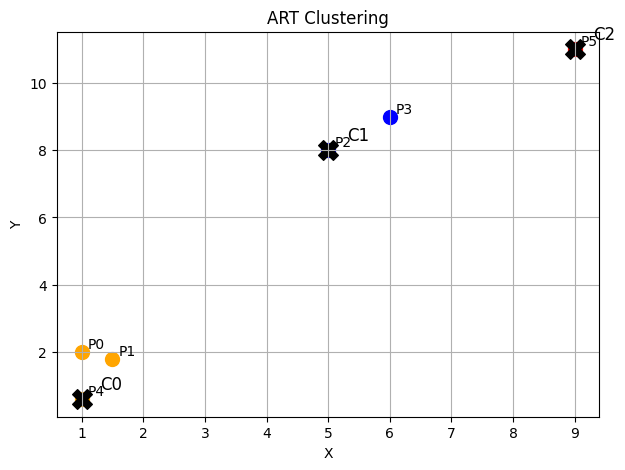

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Input patterns
patterns = np.array([
    [1, 2],
    [1.5, 1.8],
    [5, 8],
    [6, 9],
    [1, 0.6],
    [9, 11]
])

# Vigilance parameter
rho = 0.7

# Cluster storage
clusters = []
labels = []


# Similarity function
def similarity(p1, p2):

    return np.sum(np.minimum(p1, p2)) / np.sum(p1)


# ART clustering
for pattern in patterns:

    assigned = False

    for i, cluster in enumerate(clusters):

        sim = similarity(pattern, cluster)

        if sim >= rho:

            # Update cluster
            clusters[i] = np.minimum(cluster, pattern)

            labels.append(i)

            assigned = True

            break

    # Create new cluster
    if not assigned:

        clusters.append(pattern.copy())

        labels.append(len(clusters) - 1)


# Display clustering labels
print("Clustering Labels:\n")

for i in range(len(patterns)):

    print(f"P{i} {patterns[i]} -> Cluster {labels[i]}")


# Display final cluster centers
print("\nFinal Cluster Centers:\n")

for i, cluster in enumerate(clusters):

    print(f"C{i}: {cluster}")


# Colors for clusters
colors = ['orange', 'blue', 'red', 'green', 'purple']


# Plot graph
plt.figure(figsize=(7, 5))

# Plot input points
for i, point in enumerate(patterns):

    plt.scatter(
        point[0],
        point[1],
        color=colors[labels[i]],
        s=100
    )

    plt.text(
        point[0] + 0.1,
        point[1] + 0.1,
        f"P{i}",
        fontsize=10
    )

# Plot cluster centers
for i, cluster in enumerate(clusters):

    plt.scatter(
        cluster[0],
        cluster[1],
        color="black",
        marker='X',
        s=200
    )

    plt.text(
        cluster[0] + 0.3,
        cluster[1] + 0.3,
        f"C{i}",
        fontsize=12
    )

plt.title("ART Clustering")

plt.xlabel("X")

plt.ylabel("Y")

plt.grid()

plt.show()

Pattern Clustering:

Pattern 0 : [1 1 0 0 0] --> Cluster 0
Pattern 1 : [1 0 0 0 0] --> Cluster 0
Pattern 2 : [0 0 1 1 1] --> Cluster 1
Pattern 3 : [0 0 1 1 0] --> Cluster 1
Pattern 4 : [1 1 1 1 1] --> Cluster 2

Final Cluster Centers:

Cluster 0 : [1 0 0 0 0]
Cluster 1 : [0 0 1 1 0]
Cluster 2 : [1 1 1 1 1]


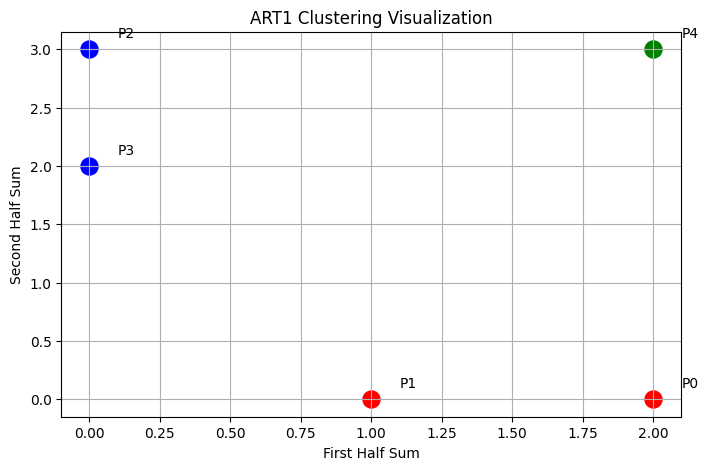

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Binary Input Patterns
# ----------------------------------------

patterns = np.array([

    [1, 1, 0, 0, 0],
    [1, 0, 0, 0, 0],

    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],

    [1, 1, 1, 1, 1]

])

# ----------------------------------------
# Vigilance Parameter
# ----------------------------------------

rho = 0.5

# ----------------------------------------
# Cluster Storage
# ----------------------------------------

clusters = []

labels = []

# ----------------------------------------
# Similarity Function
# ----------------------------------------

def similarity(p1, p2):

    # Common active bits
    common = np.sum(
        np.logical_and(p1, p2)
    )

    # Match ratio
    return common / np.sum(p1)

# ----------------------------------------
# ART Clustering
# ----------------------------------------

for pattern in patterns:

    assigned = False

    # Compare with existing clusters
    for i, cluster in enumerate(clusters):

        sim = similarity(
            pattern,
            cluster
        )

        # Vigilance Test
        if sim >= rho:

            # Update cluster
            clusters[i] = np.logical_and(
                pattern,
                cluster
            ).astype(int)

            labels.append(i)

            assigned = True

            break

    # Create new cluster
    if not assigned:

        clusters.append(pattern.copy())

        labels.append(
            len(clusters) - 1
        )

# ----------------------------------------
# Display Results
# ----------------------------------------

print("Pattern Clustering:\n")

for i in range(len(patterns)):

    print(
        f"Pattern {i} : {patterns[i]}"
        f" --> Cluster {labels[i]}"
    )

print("\nFinal Cluster Centers:\n")

for i, cluster in enumerate(clusters):

    print(
        f"Cluster {i} : {cluster}"
    )

# ----------------------------------------
# Visualization
# ----------------------------------------

plt.figure(figsize=(8,5))

colors = [
    'red',
    'blue',
    'green',
    'purple',
    'orange'
]

# Plot patterns
for i, pattern in enumerate(patterns):

    plt.scatter(

        np.sum(pattern[:2]),
        np.sum(pattern[2:]),

        color=colors[labels[i]],
        s=150

    )

    plt.text(

        np.sum(pattern[:2]) + 0.1,
        np.sum(pattern[2:]) + 0.1,

        f"P{i}"

    )

plt.xlabel("First Half Sum")

plt.ylabel("Second Half Sum")

plt.title("ART1 Clustering Visualization")

plt.grid()

plt.show()